You can order print and ebook versions of *Think Bayes 2e* from
[Bookshop.org](https://bookshop.org/a/98697/9781492089469) and
[Amazon](https://amzn.to/334eqGo) (affiliate links).

If you are enjoying the free, online version, please consider
[buying me a coffee](https://buymeacoffee.com/allendowney).

And you might like this new book-in-progress by Allen Downey, [*You Would Choose Now: Measuring America's Progress Toward Fairness and Tolerance*](https://leanpub.com/ywcn).

# Ordinal Regression

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ThinkBayes2/blob/master/examples/ordinal.ipynb).

Survey questions often ask for an answer on an ordered scale: strongly disagree
to strongly agree, poor to excellent, never to always.
Answers like these are called **ordinal** -- the categories have an order, but
the distances between them don't mean anything.
"Very happy" is happier than "pretty happy", but it is not twice as happy, and
the step from "not too happy" to "pretty happy" is not necessarily the same size
as the step from "pretty happy" to "very happy".

That makes them awkward to model.
If we assign the responses numbers and run linear regression, we are pretending
the spacing is meaningful.
If we treat them as unordered categories and run multinomial regression, we
throw away the ordering, which is important information.

Ordinal regression is the model that fits the shape of the problem.
This example develops it in two steps: first the **forward path**, computing the
probability of the data given the parameters, and then the **reverse path**, computing the posterior distribution of the parameters given the data.

This example is adapted from a workshop on
[survey data analysis with PyMC](https://allendowney.github.io/SurveyDataPyMC/).

In [1]:
# If we're running on Colab, update some libraries
# and install empiricaldist

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install --quiet --upgrade "pymc>=6" "arviz>=1" "matplotlib>=3.11" empiricaldist

In [2]:
# Get the data file

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

download('https://github.com/AllenDowney/ThinkBayes2/raw/master/data/gss_happy.csv')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit, logit

## The Question

The [General Social Survey](https://gss.norc.org/) has asked the same question
about happiness since 1972:

> Taken all together, how would you say things are these days -- would you say
> that you are very happy, pretty happy, or not too happy?

There are three possible responses, which I'll put in order from least to most
happy and label 0, 1, and 2.

In [4]:
happy_map = {0: 'Not too happy', 1: 'Pretty happy', 2: 'Very happy'}

## The Forward Model

Let's suppose each respondent has a latent level of happiness -- a number on a
continuous scale we can't observe directly.
When they answer the question, they translate that number into one of the three responses.
I'll call the latent value $\eta$ (eta), which is the conventional name for the
linear predictor in a model like this.

To model that process, we'll suppose there are **cutpoints** on the scale that
mark transitions from one response to the next.
With three responses there are two cutpoints; for now we'll pretend we know
they are at -1 and 1.

* Someone below -1 is likely to say "not too happy".
* Someone between -1 and 1 is likely to say "pretty happy".
* Someone above 1 is likely to say "very happy".

Here are the cutpoints, $c0$ and $c1$, and a range of possible values for $\eta$.

In [5]:
cutpoints = [-1, 1]
etas = np.linspace(-4, 4, 500)

For a person with a given $\eta$, the probability that they answer 0 or below is

$$P(Y \le 0) = \mathrm{expit}(c_0 - \eta)$$

where `expit` is the inverse of the logit function, which maps any number onto a
probability.
The probability that they answer 1 or below depends on the other cutpoint, $c_1$:

$$P(Y \le 1) = \mathrm{expit}(c_1 - \eta)$$

And the probability that they answer 2 or below is 1, because there is no higher
response.
Here's what that looks like in code.

In [6]:
p_le_0 = expit(cutpoints[0] - etas)
p_le_1 = expit(cutpoints[1] - etas)
p_le_2 = np.ones_like(etas)

These are **cumulative** probabilities, so together they make a cumulative distribution function (CDF).
The following function take the value of $\eta$ for a hypothetical person and plots:

* Logistic curves centered at the cutpoints.

* A vertical dashed line at the given values of $\eta$.

* Points on the logistic curves at $\eta$.


In [7]:
def plot_ordinal_cdf(eta0=0.5):
    plt.plot(etas, p_le_0, label=r'$P(Y \leq 0)$')
    plt.plot(etas, p_le_1, label=r'$P(Y \leq 1)$')
    plt.plot(etas, p_le_2, label=r'$P(Y \leq 2)$')

    for c in cutpoints:
        plt.axvline(c, ls=':', alpha=0.4)

    plt.axvline(eta0, ls='--', lw=2, color='gray',
                label=rf'$\eta={eta0}$')

    for p in [expit(cutpoints[0] - eta0), expit(cutpoints[1] - eta0), 1.0]:
        plt.plot(eta0, p, 'o', color='gray')
        plt.hlines(p, xmin=eta0, xmax=4, ls=':', alpha=0.4)

    plt.xlabel(r'Latent happiness, $\eta$')
    plt.ylabel('Cumulative probability')
    plt.title('Cumulative probabilities and cutpoints')
    plt.legend()

Here's what it looks like for someone with $\eta = 0.5$, a little happier than
average.

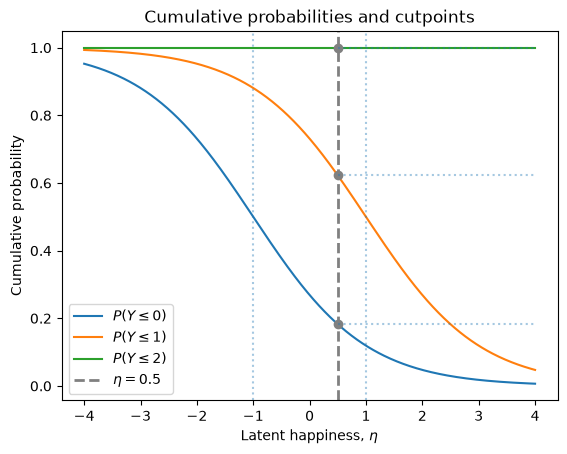

In [8]:
eta0 = 0.5
plot_ordinal_cdf(eta0)

The three dots are the CDF of their response, which we can store as the probabilities in a `Cdf` object (defined by [`empiricaldist`](https://allendowney.github.io/empiricaldist/))

In [9]:
from empiricaldist import Cdf

ps = [expit(cutpoints[0] - eta0), expit(cutpoints[1] - eta0), 1.0]
cdf = Cdf(ps, [0, 1, 2])
cdf

,probs
0,0.182426
1,0.622459
2,1.000000


And the differences between consecutive values are the probabilities of the
three responses -- the PMF.

In [10]:
pmf = cdf.make_pmf()
pmf.index = pmf.index.map(happy_map)
pmf

,probs
Not too happy,0.182426
Pretty happy,0.440034
Very happy,0.377541


So this person is most likely to say "pretty happy", with "very happy" the next
most likely.

That's the forward path: given the cutpoints and a latent value, we can compute
the probability of each response.

Now we can run it backward: given the responses, estimate the parameters.

## The Data

As data for this example we'll use an excerpt from the [General Social Survey](https://gss.norc.org/).

In [11]:
gss = pd.read_csv('gss_happy.csv')
gss.head()

,year,age,cohort,happy,sex,educ
0,1972,23.0,1949.0,3,2,16.0
1,1972,70.0,1902.0,3,1,10.0
2,1972,48.0,1924.0,2,2,12.0
3,1972,27.0,1945.0,3,2,17.0
4,1972,61.0,1911.0,2,2,12.0


The `happy` column uses 1 for "very happy" and 3 for "not too happy", so I'll
recode it to put the categories in increasing order, starting from `0`.
This coding is actually a requirement for the PyMC implementation of ordinal regression.

In [12]:
gss['y'] = gss['happy'].replace([1, 2, 3], [2, 1, 0])

Here's the distribution of responses.

In [13]:
proportions = gss['y'].value_counts(normalize=True).sort_index()
proportions.index = proportions.index.map(happy_map)
(proportions * 100).round(1)

y
Not too happy    12.8
Pretty happy     55.9
Very happy       31.3
Name: proportion, dtype: float64

Most people say they are pretty happy, and more say very happy than not too
happy.

Now let's see whether happiness varies with age.
I'll group respondents into five-year bins and compute the proportion giving
each response.

In [14]:
bins = np.arange(15, 95, 5)
gss['age_group'] = bins[np.digitize(gss['age'], bins) - 1] + 2.5

age_table = pd.crosstab(gss['age_group'], gss['y'], normalize='index') * 100
age_table.columns = age_table.columns.map(happy_map)

Text(0.5, 1.0, 'Happiness by age')

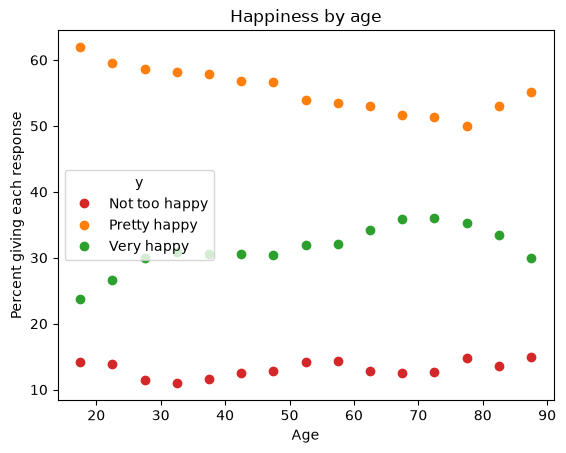

In [15]:
colors = ['C3', 'C1', 'C2']
age_table.plot(style='o', color=colors)
plt.xlabel('Age')
plt.ylabel('Percent giving each response')
plt.title('Happiness by age')

The proportion saying "very happy" rises with
age, and the proportion saying "not too happy" falls.

## The Model

Now we'll estimate the cutpoints and the effect of age.

For the cutpoints, we need a prior that generates ordered values.
PyMC provides an `ordered` transform that does exactly that.

To choose locations for the priors, we'll use the observed proportions.
Specifically, we'll use logits of the cumulative proportions.

In [16]:
cumulative = proportions.cumsum()
[round(logit(p), 2) for p in cumulative[:2]]

[np.float64(-1.92), np.float64(0.78)]

Peeking at the data to choose the priors helps the sampler get started, but it doesn't affect the results much (as long as there's enough spread in the priors).

For the effect of age, we'll use a linear model.
We'll center `age` so the parameter is easier to interpret (it also helps the sampler).

The dataset has almost 60,000 respondents, which is more than we need -- and
sampling takes about a minute with all of them.
So I'll draw a random subset of 5000, which is enough to estimate three
parameters and runs in a few seconds.

In [17]:
data = gss.dropna(subset=['y', 'age']).sample(5000)
y = data['y'].to_numpy()

age_shift = data['age'].mean()
age_centered = data['age'].to_numpy() - age_shift
age_shift.round(1)

np.float64(46.3)

Now here's the model, taking advantage of the built-in `OrderedLogistic` likelihood.

In [18]:
import pymc as pm

with pm.Model() as model:
    age_data = pm.Data('age', age_centered)

    cutpoints = pm.Normal('cutpoints',
                          mu=np.array([-2, 0.8]),
                          sigma=0.5,
                          shape=2,
                          transform=pm.distributions.transforms.ordered)
    
    beta_age = pm.Normal('beta_age', 0, 0.1)

    eta = beta_age * age_data

    pm.OrderedLogistic('y', eta=eta, cutpoints=cutpoints,
                       compute_p=True, observed=y)

There is no intercept in the linear model of `eta`.
That's deliberate -- because `OrderedLogistic` compares `eta` to the cutpoints, an intercept would shift every cutpoint by the same amount.
So adding an intercept would make the model unidentifiable: we could increase the intercept
and increase every cutpoint to match, and the likelihood would not change.

Here's a graphical representation of the model.

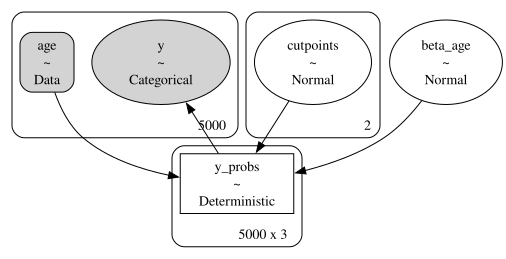

In [19]:
pm.model_to_graphviz(model)

Now we can run the sampler.

Because we set `compute_p=True`, the model contains a deterministic variable
with the probability of each response for each respondent.
That's an array with almost 60,000 rows, and if we stored it for every draw, the
result would be several gigabytes -- and we don't need it, because we'll
recompute these probabilities later for a small range of ages.
So I'll use `var_names` to store only the parameters.

In [20]:
var_names = ['cutpoints', 'beta_age']

In [21]:
with model:
    idata = pm.sample(500, tune=500, var_names=var_names)

NUTS[nutpie]: [cutpoints, beta_age]


Output()

In [22]:
import arviz as az

az.summary(idata, var_names=var_names, round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cutpoints[0],-1.936,0.043,-2.003,-1.869,827.123,1071.997,1.002,0.001,0.001
cutpoints[1],0.822,0.031,0.773,0.871,2626.386,1499.888,1.002,0.001,0.001
beta_age,0.006,0.002,0.003,0.008,1548.974,1191.611,1.002,0.000,0.000


The estimated cutpoints are close to the values we computed from the observed
proportions, which is what we'd expect, since most of the information about
where the cutpoints go is in the overall response distribution.

`beta_age` is small but clearly positive, which means older respondents are more
likely to give happier answers.

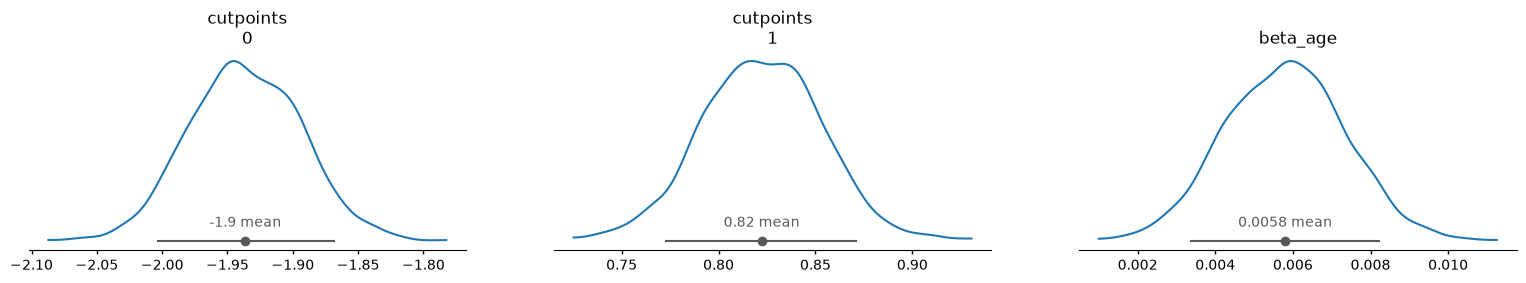

In [23]:
az.plot_dist(idata, var_names=['cutpoints', 'beta_age']);

## What the Model Predicts

A slope on a logit scale is hard to interpret directly, so let's convert it back
into probabilities.
Because we passed `compute_p=True`, PyMC computed the probability of each
response for each respondent, and we can evaluate it for any age.

In [24]:
age_range = np.arange(18, 90)

with model:
    pm.set_data({'age': age_range - age_shift})
    idata_pred = pm.compute_deterministics(idata.posterior)
    predicted = az.extract(idata_pred, var_names=['y_probs'],
                           num_samples=200) * 100

Output()

The result has an axis for age, an axis for the three responses, and an axis for
the posterior samples, so we can plot the mean and a credible interval for each
response.

In [25]:
def plot_bands(x, probs, colors):
    """Plot the mean and a 90% interval for each category."""
    for k, color in enumerate(colors):
        pk = np.asarray(probs)[:, k, :]
        plt.plot(x, pk.mean(axis=-1), color=color, alpha=0.6)
        low, high = np.percentile(pk, [5, 95], axis=-1)
        plt.fill_between(x, low, high, color=color, alpha=0.2, lw=0)

Text(0.5, 1.0, 'Happiness by age, with model predictions')

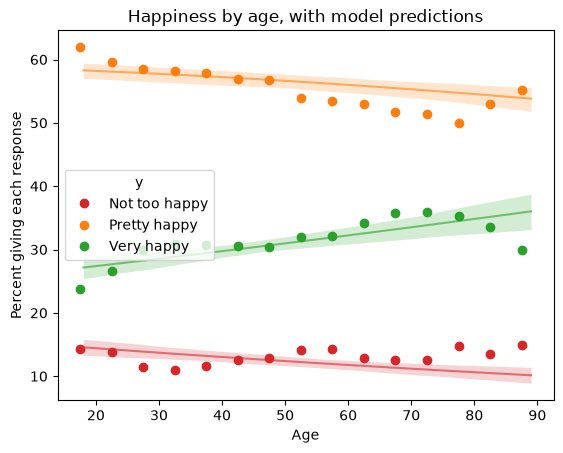

In [26]:
age_table.plot(style='o', color=colors)
plot_bands(age_range, predicted, colors)
plt.xlabel('Age')
plt.ylabel('Percent giving each response')
plt.title('Happiness by age, with model predictions')

The model captures the trends in the data, but not the details of the ups and downs.

Notice that the three curves are constrained: they always sum to 100%, they are
always in the same order, and none of them can wander outside 0 and 100.
Those constraints come from the structure of the model, not from anything we
had to impose.

## Under the Hood

`OrderedLogistic` is a convenience.
Underneath, it does exactly what we did in the forward model: it computes
cumulative probabilities from the cutpoints, differences them to get category
probabilities, and passes those to a `Categorical` distribution.

Here is the same model written out:

In [27]:
with pm.Model() as model2:
    age_data = pm.Data('age', age_centered)

    cutpoints = pm.Normal('cutpoints',
                          mu=np.array([-2, 0.8]),
                          sigma=0.5,
                          shape=2,
                          transform=pm.distributions.transforms.ordered)
    beta_age = pm.Normal('beta_age', 0, 0.1)

    eta = beta_age * age_data

    # cumulative probabilities, as in the forward model
    cdf_0 = pm.math.invlogit(cutpoints[0] - eta)
    cdf_1 = pm.math.invlogit(cutpoints[1] - eta)

    # differences, to get the probability of each response
    p = pm.math.stack([cdf_0, cdf_1 - cdf_0, 1 - cdf_1], axis=1)

    pm.Categorical('y', p=p, observed=y)

In [28]:
with model2:
    idata2 = pm.sample(500, tune=500)

NUTS[nutpie]: [cutpoints, beta_age]


Output()

In [29]:
az.summary(idata2, var_names=['cutpoints', 'beta_age'], round_to=3)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
cutpoints[0],-1.933,0.044,-2.002,-1.864,822.489,1032.171,1.002,0.002,0.001
cutpoints[1],0.822,0.030,0.774,0.872,2596.059,1563.674,1.003,0.001,0.001
beta_age,0.006,0.002,0.003,0.008,1590.263,1474.314,1.001,0.000,0.000


The results are the same, within sampling error.

## Summary

Ordinal data is common and easy to model badly.
Treating the categories as numbers assumes a spacing we don't know; treating
them as unordered categories discards the ordering we do know.

The cumulative logit model takes the middle path.
It supposes a latent quantity on a continuous scale and a set of cutpoints that
divide the scale into ordered categories.
By estimating the cutpoints along with the other parameters of the model, we infer the spacing of the responses rather than assume it.

For more on modeling survey data with PyMC, see
[this workshop](https://allendowney.github.io/SurveyDataPyMC/).

Copyright 2026 Allen B. Downey

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)